# Práctica 2: Modelo cinemático inverso de un manipulador y planteamiento de trayectoria


## Objetivo



El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa de un manipulador serial.


### Metas 

- Que el alumno aplique un modelo cinemático, obteniendo las matrices de transformación y la postura del manipulador 
- Que el alumno aplique un modelo cinemático inverso para calcular una trayectoria a partir de una posición actual hacia una posición final
- Que el alumno grafique y analice los resultados del modelo

### Contribución al perfil del egresado

La siguiente práctica contribuye en los siguientes puntos al perfil del egresado:

#### Aptitudes y habilidades

- Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.
- Para diseñar, construir, operar y mantener los sistemas mecatrónicos y sus componentes.

#### Actitudes

- Tener confianza en su preparación académica.
- Comprometido con su actualización, superación y competencia profesional.

#### De tipo social

- Promover el cambio en la mentalidad frente a la competitividad internacional.



## Rúbrica de evaluación



La evaluación de la práctica contará de los siguientes puntos y se evaluará con los siguientes criterios:

| Elemento | Porcentaje |
| ------:| -----------:|
| **Cuestionario previo** | 15% | 
| **Desarrollo** | 35% |
| **Análisis de resultados**  | 35% |
| **Conclusiones** | 15% |

<br>


| Elemento | Malo | Regular | Bueno |
| ------:| ------ | --------| ------|
| **Cuestionario previo** | El trabajo no contiene cuestionario previo o todas las preguntas son incorrectas (0%)| Al menos la mitad de las preguntas son correctas (8%) |  Todas las preguntas son correctas (15%) |
| **Desarrollo** | El trabajo no contiene desarrollo o su planteamiento no concuerda con lo deseado (0%) | El desarrollo está mal planteado o no llega a los resultados esperados (10%) | El desarrollo tiene un planteamiento adecuado y llega a los resultados esperados (35%) |
| **Análisis de resultados**  | El trabajo no contiene análisis de resultados o la información no se está interpretando correctamente (0%) | La interpretación de los resultados es parcial o desorganizada (10%) | Realiza un correcto análisis de los resultados de forma organizada   (35%) |
| **Conclusiones** | El trabajo no contiene conclusiones o no hacen referencia al trabajo desarrollado y los objetivos planteados (0%) | La redacción de las conclusiones es desorganizada o confusa (8%) | Las conclusiones del trabajo son claras y hacen referencia al trabajo desarrollado y los objetivos planteados (15%) | 



## Introducción

### Transformaciones homogéneas
Las transformaciones homogéneas permiten hacer el planteamiento del modelo cinemático de un robot, considerando las posiciones y orientaciones de las juntas del robot respecto al sistema de referencia de una junta anterior

Este planteamiento es el **modelo de cinemática directa**, que nos permite obtener la posición y velocidad del efector final de un manipulador en términos de los valores de la posición y velocidad de sus juntas (espacio de trabajo)

A través de este modelo se puede obtener el **modelo de cinemática inversa**, que permite obtener la velocidad de las juntas de un robot a partir de la velocidad deseada del efector final.

### Planteamiento de una trayectoria
Si se conoce el punto inicial y final de una trayectoria deseada, se pueden obtener los puntos intermedios de la trayectoria. La forma más fácil de realizar esta interpolación es a través de un spline. El orden del spline permitirá controlar las condiciones inicial y final de la posición, velocidad ó aceleración que tendrá el efector final durante el trayecto. 

Juntando la interpolación de la trayectoria y el modelo de la cinemática inversa, se pueden obtener todos los puntos intermedios de la trayectoria que deben seguir las juntas del robot para que el efector final siga una trayectoria.

### Inyección de dependencias en python
Al crear una clase, es posible agregar atributos y métodos a la misma, que se verán reflejados al instanciar un objeto, por ejemplo:

In [11]:
# Se define una clase
class ClaseEjemplo():
  def metodo_original(self):
    print("Metodo original")
# Fuera de la clase, se define un método nuevo
def metodo_inyectado(self):
  print("Método inyectado en la clase")
# Se asigna el método dentro de la clase
ClaseEjemplo.nuevo_metodo = metodo_inyectado
# Al instanciar el objeto, éste contiene el método inyectado
objeto = ClaseEjemplo()
objeto.nuevo_metodo()

Método inyectado en la clase


## Cuestionario previo



Responder de forma breve las siguientes preguntas:

- ¿Que son las transformaciones homogéneas?
>Son el planteamiento del modelo cinemático de un robot, que considera posición y orientación de las juntas del robot respecto al sistema de referencia de una junta anterior

- ¿Que nos permite obtener el modelo de cinemática directa de un manipulador?
>La posición y velocidad del efector final de un manipulador en términos de los valores de la posición y velocidad de sus juntas

- ¿Que nos permite obtener el modelo de cinemática inversa de un manipulador?
>La velocidad de las juntas de un robot a partir de la velocidad deseada del efector final.

- ¿De que formas se puede interpolar la trayectoria de un efector final entre dos puntos?
>A través de splines, cuyo orden permite controlar las condiciones inicial y final de la posición, velocidad ó aceleración que tendrá el efector final durante el trayecto.

## Desarrollo



### 1. Planteamiento de la cinemática directa
En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano. Se recomienda usar **Sympy** para el planteamiento de las expresiones. 
Un diagrama del robot se muestra en la imagen:

<img src="imagenes/p2_1.png" alt = "Robot RRR" width="300" height="300" display= "block"/>

** Considerar valores cualesquiera para las dimensiones de los eslabones y la posición inicial de las juntas

In [12]:
# Colocar y correr el código dentro de estas celdas.
import sympy
from sympy import *
#para un manipulador de 3GDL en el plano XY
def r_z(alpha):
  rz = Matrix([[cos(alpha), -sin(alpha), 0], 
               [sin(alpha),  cos(alpha), 0], 
               [0         ,           0, 1]])
  return rz

th1, th2, th3 = symbols("theta_1, theta_2, theta_3")
l1, l2, l3 = symbols("l_1, l_2, l_3")
p_0_1 = Matrix([[0],[0],[0]])
p_1_2 = Matrix([[l1],[0],[0]])
p_2_3 = Matrix([[l2],[0],[0]])
p_3_p = Matrix([[l3],[0],[0]])
R_0_1 = r_z(th1)
R_1_2 = r_z(th2)
R_2_3 = r_z(th3)
R_3_p = r_z(0)

def tr_h(rot, pos):
  a = Matrix.vstack(rot, Matrix([[0,0,0]]))
  b = Matrix.vstack(pos, Matrix([1]))
  t_h = Matrix.hstack(a, b)
  return t_h

T_0_1 = tr_h(R_0_1, p_0_1)
T_1_2 = tr_h(R_1_2, p_1_2)
T_2_3 = tr_h(R_2_3, p_2_3)
T_3_p = tr_h(R_3_p, p_3_p)
T_0_p = T_0_1 * T_1_2 * T_2_3 * T_3_p
T_0_p = simplify(T_0_p)

xi = Matrix([T_0_p[0, 3],
             T_0_p[1, 3],
             atan2(T_0_p[1, 0], T_0_p[0,0])])
xi = xi.subs({l1: 0.1, l2: 0.1, l3: 0.1})
simplify(xi)

J = Matrix([[diff(xi, th1), 
             diff(xi, th2), 
             diff(xi, th3)]])
J = simplify(J)
J


Matrix([
[-0.1*sin(theta_1) - 0.1*sin(theta_1 + theta_2) - 0.1*sin(theta_1 + theta_2 + theta_3), -0.1*sin(theta_1 + theta_2) - 0.1*sin(theta_1 + theta_2 + theta_3), -0.1*sin(theta_1 + theta_2 + theta_3)],
[ 0.1*cos(theta_1) + 0.1*cos(theta_1 + theta_2) + 0.1*cos(theta_1 + theta_2 + theta_3),  0.1*cos(theta_1 + theta_2) + 0.1*cos(theta_1 + theta_2 + theta_3),  0.1*cos(theta_1 + theta_2 + theta_3)],
[                                                                                    1,                                                                  1,                                     1]])

### 2. Planteamiento de la trayectoria

En esta segunda parte, se planteará el código que permita definir los puntos intermedios de una trayectoria, la cual debe tener velocidades y aceleraciones nulas al inicio y al final. Se deben incluir también las gráficas de la posición, velocidad y aceleración del efector final. 

Calcular la trayectoria considerando de forma general tiempo de duración, puntos inicial y final, y con una tasa de muestreo de 30 muestras por segundo. 

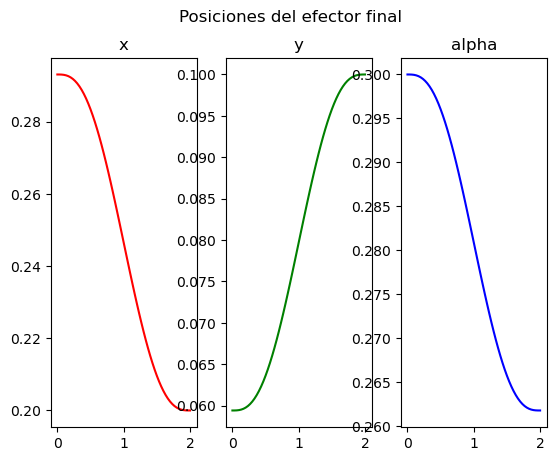

In [13]:
# Colocar y correr el código dentro de estas celdas. 
#Construcción de una trayectoria
a_0, a_1, a_2, a_3, a_4, a_5 = symbols("a_0, a_1, a_2, a_3, a_4, a_5")
t = Symbol("t")
lam = a_0 + a_1*t + a_2*t**2 + a_3*t**3 + a_4*t**4 + a_5*t**5
lam 

#derivada del polinomio
lam_dot = diff(lam, t)
lam_dot_dot = diff(lam_dot, t)

tf = 2
# Posiciones iniciales de las juntas y efector final
th1_in = 0.1
th2_in = 0.1
th3_in = 0.1
#Posición del efector final substituyendo en la postura (m , rad)
x_in = xi[0].subs({th1: th1_in, th2: th2_in, th3: th3_in})
y_in = xi[1].subs({th1: th1_in, th2: th2_in, th3: th3_in})
alpha_in = xi[2].subs({th1: th1_in, th2: th2_in, th3: th3_in})
#Posición final deseada (m, rad)
x_f = 0.2
y_f = 0.10
alpha_f = pi/12 
eq1 = lam.subs({t: 0})
eq2 = lam.subs({t: tf}) - 1
eq3 = lam_dot.subs({t: 0})
eq4 = lam_dot.subs({t: tf})
eq5 = lam_dot_dot.subs({t: 0})
eq6 = lam_dot_dot.subs({t: tf})

solutions = solve((eq1, eq2, eq3, eq4, eq5, eq6),
                  (a_0, a_1, a_2, a_3, a_4, a_5))
solutions

lam_s = lam.subs(solutions)

#Obtención de los puntos intermedios

#Posición, velocidad y aceleración en x
x_eq = x_in + lam_s*(x_f - x_in)
x_dot_eq = diff(x_eq, t)
x_dot_dot_eq = diff(x_dot_eq, t)
x_dot_eq.subs({t: 1})

#Posición, velocidad y aceleración en y
y_eq = y_in + lam_s*(y_f - y_in)
y_dot_eq = diff(y_eq, t)
y_dot_dot_eq = diff(y_dot_eq, t)

#Posición, velocidad y aceleración en alpha
alpha_eq = alpha_in + lam_s*(alpha_f - alpha_in)
alpha_dot_eq = diff(alpha_eq, t)
alpha_dot_dot_eq = diff(alpha_dot_eq, t)

#Graficar posiciones del efector final
import matplotlib
import matplotlib.pyplot as plt
#Para manejarlo de forma discreta, muestreamos a 30 muestras por segundo
frec = 30
dt = 1.0/frec
dt
samples = int(frec*tf) + 1
samples

#Generar arreglos para guardar muestreo
t_m = Matrix.zeros(1,samples)
for i in range(samples):
  t_m[i] = dt * i
t_m

# Arreglos para posición, velocidad y aceleración final del efector final:
xi_m = Matrix.zeros(3, samples)
xi_dot_m = Matrix.zeros(3, samples)
xi_dot_dot_m = Matrix.zeros(3, samples)

xi_t = Matrix([x_eq, y_eq, alpha_eq])
xi_dot_t = Matrix([x_dot_eq, y_dot_eq, alpha_dot_eq])
xi_dot_dot_t = Matrix([x_dot_dot_eq, y_dot_dot_eq, alpha_dot_dot_eq])

#Muestreo para posición, velocidad y aceleración final del efector final:
for i in range(samples):
  xi_m[:,i] = xi_t.subs({t:t_m[i]})
  xi_dot_m[:,i] = xi_dot_t.subs({t:t_m[i]})
  xi_dot_dot_m[:,i] = xi_dot_dot_t.subs({t:t_m[i]})

#Graficas de posición del efector final 

fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Posiciones del efector final")
x_g.set_title("x")
y_g.set_title("y")
al_g.set_title("alpha")
x_g.plot(t_m.T, xi_m[0, :].T, color = "RED")
y_g.plot(t_m.T, xi_m[1, :].T, color = "green")
al_g.plot(t_m.T, xi_m[2, :].T, color = (0,0,1))
plt.show()

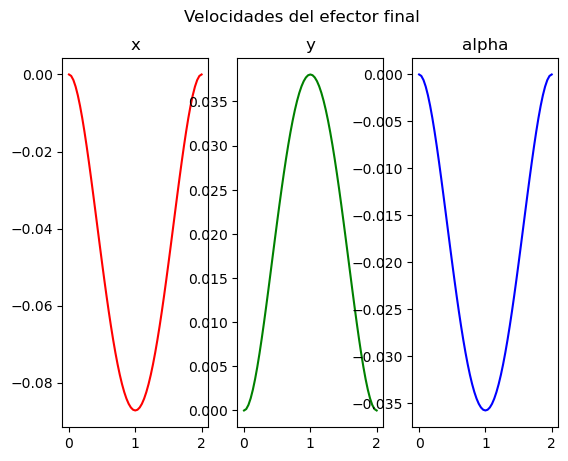

In [14]:
#Graficas de velocidad del efector final 
fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Velocidades del efector final")
x_g.set_title("x")
y_g.set_title("y")
al_g.set_title("alpha")
x_g.plot(t_m.T, xi_dot_m[0, :].T, color = "RED")
y_g.plot(t_m.T, xi_dot_m[1, :].T, color = "green")
al_g.plot(t_m.T, xi_dot_m[2, :].T, color = (0,0,1))
plt.show()

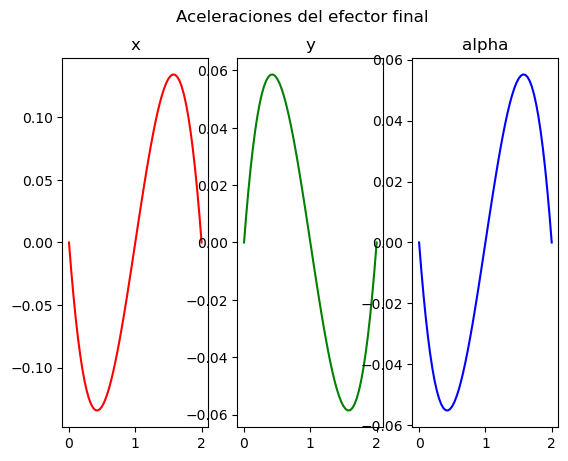

In [15]:
#Graficas de aceleración del efector final 
fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Aceleraciones del efector final")
x_g.set_title("x")
y_g.set_title("y")
al_g.set_title("alpha")
x_g.plot(t_m.T, xi_dot_dot_m[0, :].T, color = "RED")
y_g.plot(t_m.T, xi_dot_dot_m[1, :].T, color = "green")
al_g.plot(t_m.T, xi_dot_dot_m[2, :].T, color = (0,0,1))
plt.show()

### 3. Cinemática inversa
A partir del modelo de la cinemática directa, obtener la expresión de la cinemática inversa, que relacione las velocidades de las juntas del robot con la velocidad del efector final. Ya que el modelo de cinemática inversa sólo permite obtener velocidades, obtener también expresiones que permitan obtener la posición de las juntas y sus aceleraciones

In [16]:
# Colocar y correr el código dentro de estas celdas.
J_inv = simplify(J.inverse())
J_inv
 
#Definiendo las variables de velocidad de las juntas y efector final
th1_dot, th2_dot, th3_dot = symbols("theta_1_dot, theta_2_dot, theta_3_dot")
x_dot, y_dot, alpha_dot = symbols("x_dot, y_dot, alpha_dot")

#Velocidades del efector final
xi_dot = Matrix([x_dot, y_dot, alpha_dot])
xi_dot

#velocidad angular de las juntas
th_dot = J_inv * xi_dot

th_dot = th_dot.subs({l1: 0.1, l2: 0.1, l3:0.1})
th_dot.subs({th1: pi/4,
             th2: pi/4,
             th3: pi/4,
             x_dot: 0.1,
             y_dot:-0.1,
             alpha_dot:0})

#Arreglo para posición y velocidad de las juntas
th_m = Matrix.zeros(3, samples)
th_dot_m = Matrix.zeros(3, samples)
th_dot_dot_m = Matrix.zeros(3, samples)
th_m[:,0] = Matrix([th1_in, th2_in, th3_in])
#Cinematica inversa
for i in range(samples):
  th_dot_m[:, i] = (th_dot.subs({th1: th_m[0,i], th2: th_m[1,i], th3: th_m[2,i],
                               x_dot: xi_dot_m[0,i], y_dot: xi_dot_m[1,i],
                               alpha_dot: xi_dot_m[2,i]})).evalf()
  if i < samples - 1:
    th_m[:,i+1] = th_m[:, i] + th_dot_m[:, i] * dt
  if i > 0:
    th_dot_dot_m[:,i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1])/dt
th_dot_dot_m 

Matrix([
[ -1.0109559679273, -2.80506760574285, -3.79760136635751, -3.59685400636622, -2.71209508623558, -1.84805265128336, -1.22624853860746, -0.80174069892101, -0.500804597125144, -0.274539681787296, -0.0949083730416422, 0.0540224043122561,  0.181601201078277,  0.293550412339197,  0.393516402517541,  0.483896971649269,   0.566297539314877,  0.641791895615355,  0.711076806054058,  0.774567142341565,  0.832456824937335,  0.884759842984305,  0.931339776105271,  0.971933056589118,    1.00616941700874,    1.03359191341256,   1.05367824543952,   1.0658646131085,  1.06957293835007,  1.06424186716121,  1.04936151609045,  1.02451141981558,  0.98940058318748, 0.943907972516685, 0.888121249900622,  0.82237113104803, 0.747258509824047, 0.663671515315285, 0.572790002202195, 0.476075637737723, 0.375246704102674, 0.272237895552194, 0.169146622843127, 0.0681684856035905, -0.0284745161826996, -0.118608904352083, -0.200183504979168, -0.27133806289538, -0.330463209270561, -0.376249019491301, -0.4077201

### 4. Aplicación de la cinemática inversa
Finalmente, a partir de los puntos de la trayectoria y el modelo de cinemática inversa, obtener las posiciones, velocidades y aceleraciones de las juntas del robot, así como sus gráficas en función del tiempo

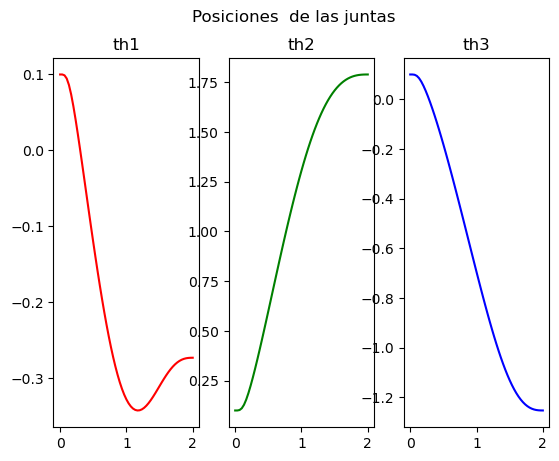

In [17]:
# Colocar y correr el código dentro de estas celdas. 
#Graficas de posicion de la cinematica inversa
fig, (th1_g, th2_g, th3_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Posiciones  de las juntas")
th1_g.set_title("th1")
th2_g.set_title("th2")
th3_g.set_title("th3")
th1_g.plot(t_m.T, th_m[0, :].T, color = "RED")
th2_g.plot(t_m.T, th_m[1, :].T, color = "green")
th3_g.plot(t_m.T, th_m[2, :].T, color = (0,0,1))
plt.show()

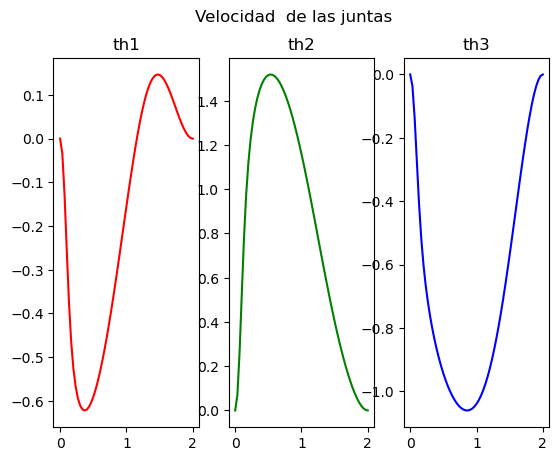

In [18]:
#Graficas de velocidad de la cinematica inversa 
fig, (th1_dot_g, th2_dot_g, th3_dot_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Velocidad  de las juntas")
th1_dot_g.set_title("th1")
th2_dot_g.set_title("th2")
th3_dot_g.set_title("th3")
th1_dot_g.plot(t_m.T, th_dot_m[0, :].T, color = "RED")
th2_dot_g.plot(t_m.T, th_dot_m[1, :].T, color = "green")
th3_dot_g.plot(t_m.T, th_dot_m[2, :].T, color = (0,0,1))
plt.show()

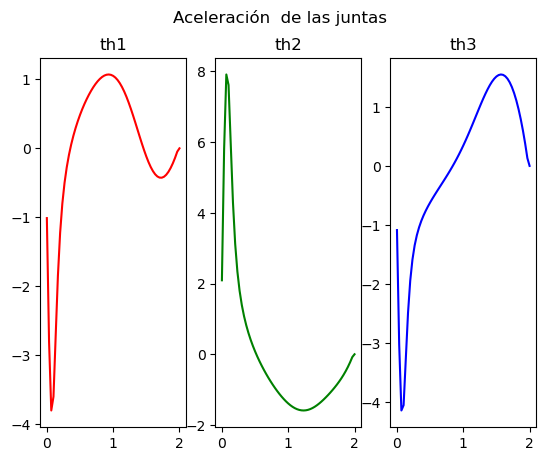

In [19]:
#Graficas de aceleracion de la cinematica inversa
fig, (th1_dot_dot_g, th2_dot_dot_g, th3_dot_dot_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Aceleración  de las juntas")
th1_dot_dot_g.set_title("th1")
th2_dot_dot_g.set_title("th2")
th3_dot_dot_g.set_title("th3")
th1_dot_dot_g.plot(t_m.T, th_dot_dot_m[0, :].T, color = "RED")
th2_dot_dot_g.plot(t_m.T, th_dot_dot_m[1, :].T, color = "green")
th3_dot_dot_g.plot(t_m.T, th_dot_dot_m[2, :].T, color = (0,0,1))
plt.show()

### 5. Repositorio
Para terminar, subir los archivos de la práctica al repositorio de github

## Análisis de resultados



- ¿Qué utilidad tiene el modelo de cinemática inversa de un robot?
> Permite calcular los ángulos o posiciones de las juntas del robot apartir de una posición y orientación deseadas para el efector final, es decir, le indica al robot cómo debe mover cada junta para alcanzar un punto específico en el espacio.




## Conclusiones



>La obtención de las transformaciones homogéneas y el modelo de cinemática directa, son herramientas muy importantes para describir la posición y orientación del efector final en función de las variables de las juntas. Para crear las matrices de trasnformación, se tuvo que plantear primero la matriz de posición y posteriormente la matriz de rotación, teniendo las matrices de trasnformación se obtiene el vector de postura que se deriva con respecto a cada variable del efector final para obtener el jacobiano.

>Posteriormente, se implementó el planteamiento de trayectorias mediante la definición de puntos intermedios y la generación de perfiles de movimiento con velocidades y aceleraciones iniciales y finales nulas. Esta condición permite obtener desplazamientos suaves y continuos, reduciendo cambios bruscos en el movimiento y asegurando una transición adecuada entre los diferentes puntos de la trayectoria.

>Finalmente, utilizando las ecuaciones de la cinemática directa, se derivó la expresión de la cinemática inversa, lo que permitió determinar las configuraciones de las juntas necesarias para alcanzar la posición específica del efector final. Con ello se corroboró la relación bidireccional entre ambos modelos y la importancia que tiene en la planificación y ejecución de movimientos. Por último, cabe destacar la metodología necesaria para modelar, planificar y controlar el movimiento de un manipulador, ya que integra conceptos fundamentales de robótica que sirven como base para el desarrollo de sistemas de control más avanzados como el seguimiento de un trayectoria.



## Bibliografía 



[1] P. Corke, *Robotics Toolbox for Python Documentation*. Disponible en: [Robotics Toolbox for Python Documentation](https://petercorke.github.io/robotics-toolbox-python/). Consultado: mayo 2026.

[2] P. Corke, “Inverse Kinematics — Robotics Toolbox for Python Documentation.” Disponible en: [Inverse Kinematics Documentation](https://petercorke.github.io/robotics-toolbox-python/IK/ik.html). Consultado: mayo 2026. 

[3] P. Corke, “Kinematics,” GitHub Wiki, 2021. Disponible en: [Robotics Toolbox Python GitHub Wiki](https://github.com/petercorke/robotics-toolbox-python/wiki/Kinematics). Consultado: mayo 2026. 
